### Here I will create 3 classifications based on claims 0-1: low risk, 2-4: medium risk, 5 and above: high risk. I will try different models with this classification problem and see how they perform.

In [9]:
# Section of all imported libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
# Loading dataset
df = pd.read_csv("../data/Cleaned_data_train.csv")
df = df.drop(["Area_A", "Area_B", "Area_C", "Area_D", "Area_E", "Area_F"], axis=1)
df

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehBrand_B1,VehBrand_B10,VehBrand_B11,...,Region_R53,Region_R54,Region_R72,Region_R73,Region_R74,Region_R82,Region_R83,Region_R91,Region_R93,Region_R94
0,0,0.43,7,18,36,95,1054,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.10,7,17,80,95,598,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.33,7,3,36,76,4172,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0.56,5,4,73,52,15,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.27,8,0,37,50,3021,0,0,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542405,0,0.20,6,10,32,76,1314,0,0,0,...,0,0,0,0,0,0,0,0,0,0
542406,0,0.06,10,14,34,60,685,0,0,0,...,0,0,1,0,0,0,0,0,0,0
542407,0,0.34,6,8,32,95,242,0,0,0,...,0,0,0,0,0,1,0,0,0,0
542408,0,0.72,9,7,39,72,3301,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [13]:
# Initialising the target variable (claims) and chaging to their repective class.
def risk_category(x):
    if x <= 1:
        return "low risk"
    elif x <= 4:
        return "medium risk"
    else:
        return "high risk"
    
dfClass = df

dfClass["RiskClass"] = dfClass["ClaimNb"].apply(risk_category)

y = dfClass["RiskClass"]

X = dfClass.drop(["RiskClass", "ClaimNb"], axis=1)


#### First let's try random forest classification

Confusion Matrix:
[[     0      1      0]
 [     0 108182      2]
 [     0    297      0]]

Classification Report:


c:\Users\nikol\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nikol\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nikol\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

   high risk       0.00      0.00      0.00         1
    low risk       1.00      1.00      1.00    108184
 medium risk       0.00      0.00      0.00       297

    accuracy                           1.00    108482
   macro avg       0.33      0.33      0.33    108482
weighted avg       0.99      1.00      1.00    108482



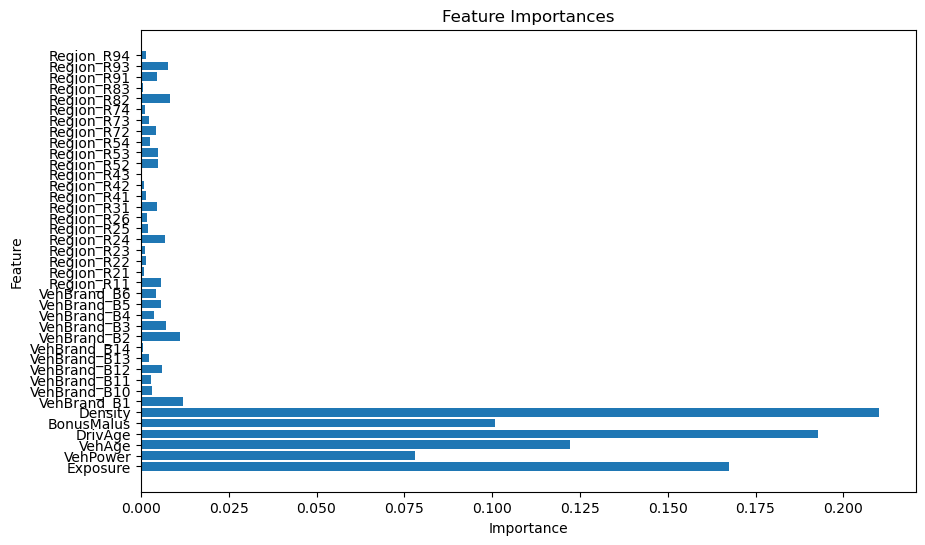

In [16]:
# ------------------------------
# 3. Train/Test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=None, stratify=y
)

# ------------------------------
# 4. Create and train Random Forest
# ------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ------------------------------
# 5. Predictions
# ------------------------------
y_pred = rf.predict(X_test)

# ------------------------------
# 6. Evaluation
# ------------------------------
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ------------------------------
# 7. Feature importance (optional)
# ------------------------------
importances = rf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()